# 04 — ML Models (LightGBM / XGBoost)
Train gradient boosting models on the full feature matrix. Compare against baselines from notebook 03.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from src.features import build_feature_matrix
from src.backtest import walk_forward_backtest
from src.evaluate import compile_metrics, save_metrics, plot_predictions, plot_shap_summary
from src.models.ml_models import LightGBMForecaster, XGBoostForecaster

df_raw = pd.read_csv('../data/raw/macro_raw.csv', index_col='date', parse_dates=True)
print('Loaded raw data')

Loaded raw data


In [2]:
target = 'cpi'
results = []

# SỬA 1: Chỉ chạy horizon 1 (hoặc đọc trực tiếp biến này từ config.yaml)
for horizon in [1]: 
    X, y = build_feature_matrix(df_raw, target_col=target, forecast_horizon=horizon)
    print(f'\nHorizon h={horizon}: {X.shape[1]} features, {len(y)} samples')

    for ModelClass, name in [
        (LightGBMForecaster, 'LightGBM'),
        # (XGBoostForecaster, 'XGBoost'), # SỬA 2: Tạm comment XGBoost lại nếu vẫn muốn test tốc độ trước
    ]:
        model = ModelClass()
        print(f'  Running {name}...')
        
        # SỬA 3: Tăng min_train_size lên để giảm số nếp gấp (folds) phải train lại
        result = walk_forward_backtest(X, y, model, model_name=name, horizon=horizon, min_train_size=120) 
        results.append(result)
        print(f'    RMSE={result.rmse:.4f}  MAE={result.mae:.4f}  MAPE={result.mape:.2f}%')


Horizon h=1: 154 features, 384 samples
  Running LightGBM...
    RMSE=0.0031  MAE=0.0021  MAPE=319.52%


In [3]:
# Compare all results
metrics_df = compile_metrics(results)
print(metrics_df.to_string(index=False))

   model  horizon   rmse    mae  mape_%  n_predictions
LightGBM        1 0.0031 0.0021  319.52            264


Figure saved → C:\Users\ADMIN\Downloads\macro-nowcasting\macro-nowcasting\outputs\figures\pred_LightGBM_h1.png


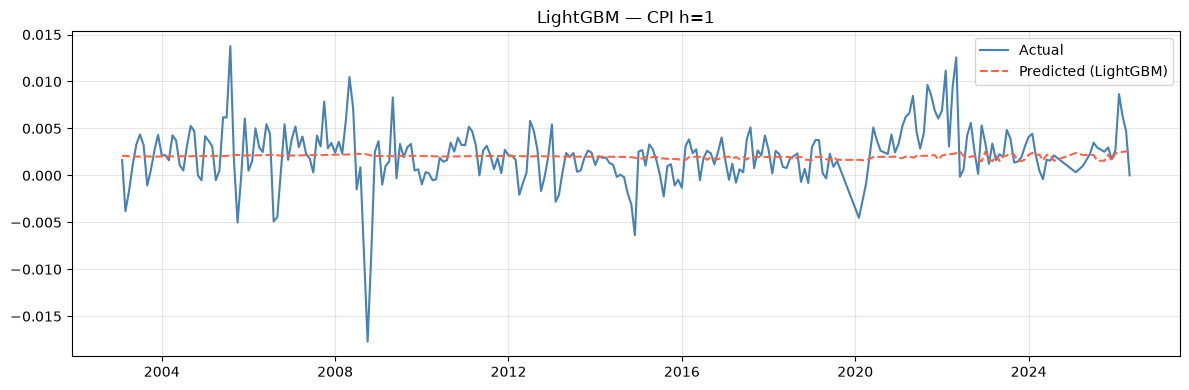

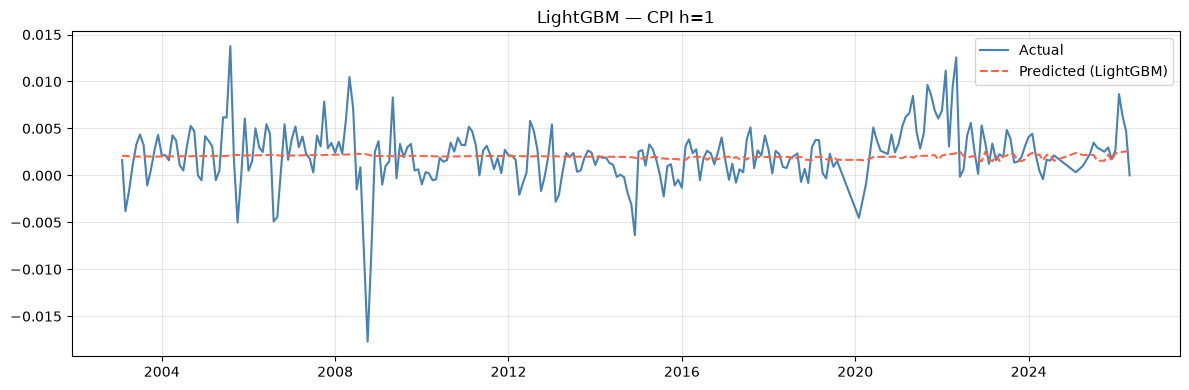

In [4]:
# Plot best ML model predictions
best = min(results, key=lambda r: r.rmse)
plot_predictions(best, title=f'{best.model_name} — {target.upper()} h={best.horizon}')

## SHAP Feature Importance
Train on full dataset (not walk-forward) to get stable SHAP values for the final report/README.

SHAP bar plot saved → C:\Users\ADMIN\Downloads\macro-nowcasting\macro-nowcasting\outputs\figures\shap_bar_LightGBM_cpi_h1.png


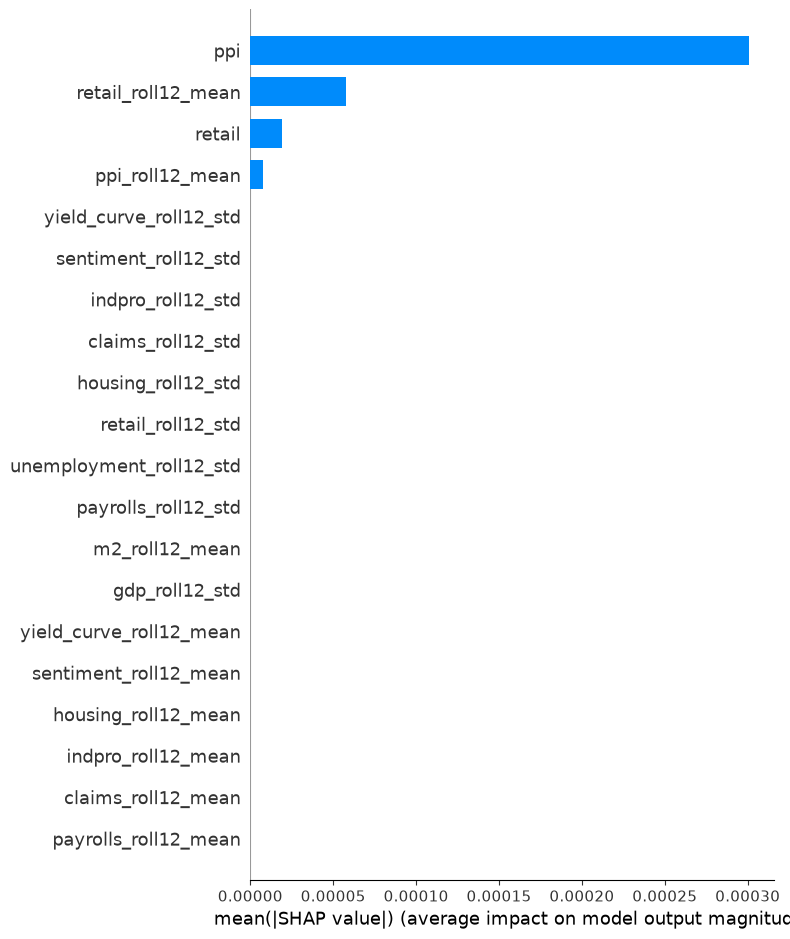

SHAP beeswarm saved → C:\Users\ADMIN\Downloads\macro-nowcasting\macro-nowcasting\outputs\figures\shap_beeswarm_LightGBM_cpi_h1.png


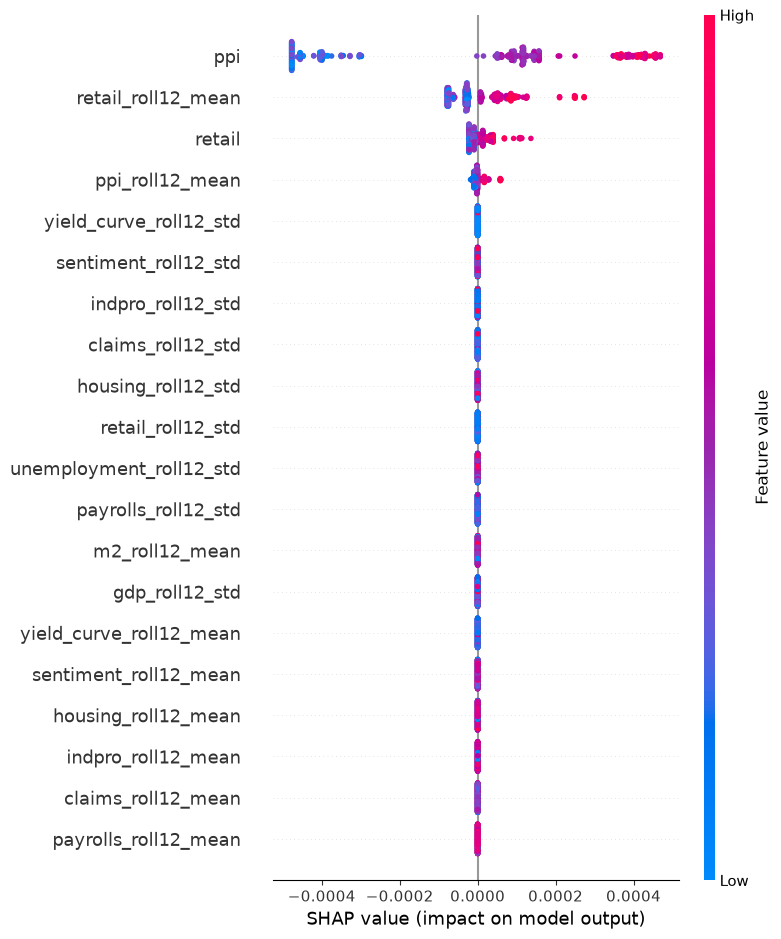

SHAP plots saved to outputs/figures/


In [5]:
X_full, y_full = build_feature_matrix(df_raw, target_col='cpi', forecast_horizon=1)
lgbm = LightGBMForecaster()
lgbm.fit(X_full, y_full)
plot_shap_summary(lgbm._model, X_full, model_name='LightGBM_cpi_h1')
print('SHAP plots saved to outputs/figures/')

In [6]:
# Load baseline metrics and append ML results
try:
    baseline_df = pd.read_csv('../outputs/metrics.csv')
    all_metrics = pd.concat([baseline_df, metrics_df], ignore_index=True)
except FileNotFoundError:
    all_metrics = metrics_df

all_metrics = all_metrics.sort_values(['horizon', 'rmse'])
save_metrics(all_metrics)
all_metrics

Metrics saved → C:\Users\ADMIN\Downloads\macro-nowcasting\macro-nowcasting\outputs\metrics.csv


,model,horizon,rmse,mae,mape_%,n_predictions
0,"ARIMA(2,0,1)",1,0.0027,0.0018,255.15,324
1,SARIMA,1,0.0029,0.0021,193.88,324
2,Naive,1,0.0031,0.0022,294.04,324
9,LightGBM,1,0.0031,0.0021,319.52,264
3,"ARIMA(2,0,1)",2,0.0028,0.0019,256.96,323
4,SARIMA,2,0.0030,0.0021,192.91,323
5,Naive,2,0.0032,0.0023,293.17,323
6,"ARIMA(2,0,1)",4,0.0027,0.0018,252.94,321
7,SARIMA,4,0.0029,0.0021,193.69,321
8,Naive,4,0.0031,0.0022,292.88,321
